# STAT53894 - Exploratory Data Analysis (EDA)
## Assignment 2

**Student Name:** Afolabi Adesina 
**Class Number:** STAT53894  
**Date:** Febuary 12, 2026

### **Global Happiness Analysis (2020-2024)**

**Data Source:** `https://files.worldhappiness.report/WHR25_Data_Figure_2.1v3.xlsx`


# Table of Contents
1. [Part 1: Data Foundations & Cleaning](#part-1)
2. [Part 2: Exploratory Data Analysis (EDA)](#part-2)
3. [Part 3: Multivariate Analysis & Visualization](#part-3)
4. [4. Data Methodology Challenge](#part-4)



### Setup
I will start by importing the necessary libraries and loading the selected dataset.

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#Set display options for better visibility of data
pd.set_option('display.max_rows', None)  # Show all rows in output
pd.set_option('display.max_columns', None)  # Show all columns in output
pd.set_option('display.width', 1000)  # Set display width for better readability


<a id="part-1"></a>
## Part 1: Data Foundations & Cleaning


**1. Filtering: Filter the master dataset to include only records from 2020 to 2024.**

In [232]:
# Load the dataset
df = pd.read_excel('WHR25_Data_Figure_2.1v3.xlsx')
df.info() # Check for data types and missing values

# Rename columns for easier access 
df.rename(columns={
    'Life evaluation (3-year average)': 'Life_Evaluation(3yr_Avg)',
    'Explained by: Log GDP per capita': 'Log_GDP',
    'Explained by: Social support': 'Social_Support',
    'Explained by: Healthy life expectancy': 'Healthy_Life_Expectancy',
    'Explained by: Freedom to make life choices': 'Freedom',
    'Country name': 'Country',
    'Lower whisker' : 'Lower_Whisker',
    'Upper whisker' : 'Upper_Whisker',
    'Explained by: Generosity': 'Generosity_index',
    'Dystopia + residual': 'Dystopia_+_Residual',
    'Explained by: Perceptions of corruption': 'Corruption_index'
}, inplace=True)

print("    ") # Just for better separation in output
display(df.head()) # Check the first few rows to confirm changes

print("    ") # Just for better separation in output
print("Shape of the original DataFrame:", df.shape)
print("    ") # Just for better separation in output

df.info() # Check for missing values and data types again after renaming

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        1969 non-null   int64  
 1   Rank                                        1969 non-null   int64  
 2   Country name                                1969 non-null   object 
 3   Life evaluation (3-year average)            1969 non-null   float64
 4   Lower whisker                               875 non-null    float64
 5   Upper whisker                               875 non-null    float64
 6   Explained by: Log GDP per capita            872 non-null    float64
 7   Explained by: Social support                872 non-null    float64
 8   Explained by: Healthy life expectancy       870 non-null    float64
 9   Explained by: Freedom to make life choices  871 non-null    float64
 10  Explained by

,Year,Rank,Country,Life_Evaluation(3yr_Avg),Lower_Whisker,Upper_Whisker,Log_GDP,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity_index,Corruption_index,Dystopia_+_Residual
0,2024,147,Afghanistan,1.364,1.301,1.427,0.649,0.0,0.155,0.0,0.075,0.135,0.348
1,2023,143,Afghanistan,1.721,1.667,1.775,0.628,0.0,0.242,0.0,0.091,0.088,0.672
2,2022,137,Afghanistan,1.859,1.795,1.923,0.645,0.0,0.087,0.0,0.093,0.059,0.976
3,2021,146,Afghanistan,2.404,2.339,2.469,0.758,0.0,0.289,0.0,0.089,0.005,1.263
4,2020,150,Afghanistan,2.523,2.449,2.596,0.370,0.0,0.126,0.0,0.122,0.010,1.895


    
Shape of the original DataFrame: (1969, 13)
    
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      1969 non-null   int64  
 1   Rank                      1969 non-null   int64  
 2   Country                   1969 non-null   object 
 3   Life_Evaluation(3yr_Avg)  1969 non-null   float64
 4   Lower_Whisker             875 non-null    float64
 5   Upper_Whisker             875 non-null    float64
 6   Log_GDP                   872 non-null    float64
 7   Social_Support            872 non-null    float64
 8   Healthy_Life_Expectancy   870 non-null    float64
 9   Freedom                   871 non-null    float64
 10  Generosity_index          872 non-null    float64
 11  Corruption_index          871 non-null    float64
 12  Dystopia_+_Residual       868 non-null    float64
dtypes: float6

In [233]:
# 1. Filter: Keep only records from 2020 to 2024
df_clean = df[(df['Year'] >= 2020) & (df['Year'] <= 2024)].copy()

print(f"Data shape after filtering: {df_clean.shape}")
print("    ") # Just for better separation in output
df_clean.info() # Check for missing values 

Data shape after filtering: (722, 13)
    
<class 'pandas.core.frame.DataFrame'>
Index: 722 entries, 0 to 1960
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      722 non-null    int64  
 1   Rank                      722 non-null    int64  
 2   Country                   722 non-null    object 
 3   Life_Evaluation(3yr_Avg)  722 non-null    float64
 4   Lower_Whisker             722 non-null    float64
 5   Upper_Whisker             722 non-null    float64
 6   Log_GDP                   719 non-null    float64
 7   Social_Support            719 non-null    float64
 8   Healthy_Life_Expectancy   717 non-null    float64
 9   Freedom                   718 non-null    float64
 10  Generosity_index          719 non-null    float64
 11  Corruption_index          718 non-null    float64
 12  Dystopia_+_Residual       715 non-null    float64
dtypes: float64(10), int64(2), 

In [234]:
# 2. Imputation
cols_to_fix = ['Log_GDP', 'Social_Support','Healthy_Life_Expectancy','Freedom','Generosity_index', 'Corruption_index','Dystopia_+_Residual']

for col in cols_to_fix:
    # Fill with country-specific mean first
    df_clean[col] = df_clean[col].fillna(df_clean.groupby('Country')[col].transform('mean'))
    
    # Fill remaining with global median (Robust Imputation)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after imputation:\n", df_clean[cols_to_fix].isnull().sum())

print("    ") # Just for better separation in output
df_clean.info()


Missing values after imputation:
 Log_GDP                    0
Social_Support             0
Healthy_Life_Expectancy    0
Freedom                    0
Generosity_index           0
Corruption_index           0
Dystopia_+_Residual        0
dtype: int64
    
<class 'pandas.core.frame.DataFrame'>
Index: 722 entries, 0 to 1960
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      722 non-null    int64  
 1   Rank                      722 non-null    int64  
 2   Country                   722 non-null    object 
 3   Life_Evaluation(3yr_Avg)  722 non-null    float64
 4   Lower_Whisker             722 non-null    float64
 5   Upper_Whisker             722 non-null    float64
 6   Log_GDP                   722 non-null    float64
 7   Social_Support            722 non-null    float64
 8   Healthy_Life_Expectancy   722 non-null    float64
 9   Freedom                   722 non-

In [235]:

# Check for unique country names to identify inconsistencies
unique_countries = sorted(df_clean['Country'].unique())

# Print all countries to visually scan for duplicates or variations
print("Unique Country Names found in dataset:")
for country in unique_countries:
    print(country)

# specific checks for common issues
possible_issues = ['US', 'USA', 'United States', 'Turkiye', 'Turkey', 'Czech Republic','Viet Nam', 'Czechia',  'Russian Federation', 'Taiwan Province of China','Hong Kong SAR of China']
print("\nChecking for specific inconsistent pairs:")
print(df_clean[df_clean['Country'].isin(possible_issues)]['Country'].unique())




Unique Country Names found in dataset:
Afghanistan
Albania
Algeria
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahrain
Bangladesh
Belarus
Belgium
Belize
Benin
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
Bulgaria
Burkina Faso
Burundi
Cambodia
Cameroon
Canada
Chad
Chile
China
Colombia
Comoros
Congo
Costa Rica
Croatia
Cyprus
Czechia
Côte d’Ivoire
DR Congo
Denmark
Dominican Republic
Ecuador
Egypt
El Salvador
Estonia
Eswatini
Ethiopia
Finland
France
Gabon
Gambia
Georgia
Germany
Ghana
Greece
Guatemala
Guinea
Haiti
Honduras
Hong Kong SAR of China
Hungary
Iceland
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Jamaica
Japan
Jordan
Kazakhstan
Kenya
Kosovo
Kuwait
Kyrgyzstan
Lao PDR
Latvia
Lebanon
Lesotho
Liberia
Libya
Lithuania
Luxembourg
Madagascar
Malawi
Malaysia
Maldives
Mali
Malta
Mauritania
Mauritius
Mexico
Mongolia
Montenegro
Morocco
Mozambique
Myanmar
Namibia
Nepal
Netherlands
New Zealand
Nicaragua
Niger
Nigeria
North Cyprus
North Macedonia
Norway
Oman
Pakistan
Panama
Paraguay
Peru
P

In [236]:
# 3. Standardization
import pandas as pd

# 1. MANUAL MAPPING DICTIONARY

country_mapping = {
    # Asia / Pacific
    "Viet Nam": "Vietnam",
    "Taiwan Province of China": "Taiwan",
    "Hong Kong SAR of China": "Hong Kong",
    "Hong Kong S.A.R. of China": "Hong Kong",
    "Republic of Korea": "South Korea",
    "Lao PDR": "Laos",
    
    # Europe / Eurasia
    "Czechia": "Czech Republic",
    "Russian Federation": "Russia",
    "Republic of Moldova": "Moldova",
    "North Macedonia": "Macedonia",
    
    # Middle East / Africa
    "Türkiye": "Turkey",
    "Turkiye": "Turkey",
    "State of Palestine": "Palestinian Territories",
    "Palestinian Territories": "Palestinian Territories",
    "Congo (Kinshasa)": "DR Congo",
    "Congo (Brazzaville)": "Congo",
    "Eswatini": "Swaziland" 
}

# 2. THE CLEANING FUNCTION
def standardize_country(name):
    if pd.isna(name):
        return None
        
    # Clean whitespace
    name = str(name).strip()
    
    # Check our manual dictionary first
    if name in country_mapping:
        return country_mapping[name]
    
    # If not in our specific list, return the name as-is
    return name

# 3. APPLY TO  DATAFRAME

# Create a copy to be safe (good practice)
df_clean = df_clean.copy() 

# Apply the standardization
df_clean['Country'] = df_clean['Country'].apply(standardize_country)

# 4. VERIFICATION

# Check if the specific problem countries are fixed
check_list = ["Vietnam", "Taiwan", "Hong Kong", "Turkey", "Russia"]
print("Verification - Checking for standardized names:")
found_countries = df_clean[df_clean['Country'].isin(check_list)]['Country'].unique()
print(found_countries)

Verification - Checking for standardized names:
['Hong Kong' 'Russia' 'Taiwan' 'Turkey' 'Vietnam']


<a id="part-2"></a>
## Part 2: Exploratory Data Analysis (EDA)


**1. Rankings: Identify the top 10 and bottom 10 countries for the most recent year available.**

In [237]:
# Rankings for the most recent year available (2024)

df_2024 = df_clean[df_clean['Year'] == 2024]

top_10 = df_2024.nlargest(10, 'Life_Evaluation(3yr_Avg)')[['Country', 'Life_Evaluation(3yr_Avg)']] 

bottom_10 = df_2024.nsmallest(10, 'Life_Evaluation(3yr_Avg)')[['Country', 'Life_Evaluation(3yr_Avg)']]

print("Top 10 Happiest:")
print(top_10.to_string(index=False))

print("\nBottom 10 Least Happy:")
print(bottom_10.to_string(index=False))

Top 10 Happiest:
    Country  Life_Evaluation(3yr_Avg)
    Finland                     7.736
    Denmark                     7.521
    Iceland                     7.515
     Sweden                     7.345
Netherlands                     7.306
 Costa Rica                     7.274
     Norway                     7.262
     Israel                     7.234
 Luxembourg                     7.122
     Mexico                     6.979

Bottom 10 Least Happy:
     Country  Life_Evaluation(3yr_Avg)
 Afghanistan                     1.364
Sierra Leone                     2.998
     Lebanon                     3.188
      Malawi                     3.260
    Zimbabwe                     3.396
    Botswana                     3.438
    DR Congo                     3.469
       Yemen                     3.561
     Comoros                     3.754
     Lesotho                     3.757


**2. Regional Comparison: Compare the Life Ladder mean and variance between Western Europe and Sub-Saharan Africa.**


In [238]:
# ROBUST REGION MAPPING 
country_to_region = {
    # --- Western Europe ---
    "Finland": "Western Europe", "Denmark": "Western Europe", "Iceland": "Western Europe", 
    "Sweden": "Western Europe", "Netherlands": "Western Europe", "Norway": "Western Europe", 
    "Switzerland": "Western Europe", "Luxembourg": "Western Europe", "Germany": "Western Europe", 
    "Austria": "Western Europe", "United Kingdom": "Western Europe", "Ireland": "Western Europe", 
    "Belgium": "Western Europe", "France": "Western Europe", "Spain": "Western Europe", 
    "Italy": "Western Europe", "Portugal": "Western Europe", "Malta": "Western Europe", 
    "Cyprus": "Western Europe", "Greece": "Western Europe", "North Cyprus": "Western Europe",
    
    # --- North America and ANZ ---
    "United States": "North America and ANZ", "Canada": "North America and ANZ", 
    "Australia": "North America and ANZ", "New Zealand": "North America and ANZ",
    
    # --- Middle East and North Africa ---
    "Israel": "Middle East and North Africa", "United Arab Emirates": "Middle East and North Africa", 
    "Saudi Arabia": "Middle East and North Africa", "Bahrain": "Middle East and North Africa", 
    "Kuwait": "Middle East and North Africa", "Iraq": "Middle East and North Africa", 
    "Iran": "Middle East and North Africa", "Turkey": "Middle East and North Africa", 
    "Morocco": "Middle East and North Africa", "Algeria": "Middle East and North Africa", 
    "Tunisia": "Middle East and North Africa", "Libya": "Middle East and North Africa", 
    "Egypt": "Middle East and North Africa", "Jordan": "Middle East and North Africa", 
    "Lebanon": "Middle East and North Africa", "Yemen": "Middle East and North Africa", 
    "Palestinian Territories": "Middle East and North Africa", "Oman": "Middle East and North Africa",
    
    # --- Latin America and Caribbean ---
    "Costa Rica": "Latin America and Caribbean", "Guatemala": "Latin America and Caribbean", 
    "Uruguay": "Latin America and Caribbean", "Chile": "Latin America and Caribbean", 
    "Mexico": "Latin America and Caribbean", "Panama": "Latin America and Caribbean", 
    "Brazil": "Latin America and Caribbean", "Argentina": "Latin America and Caribbean", 
    "Honduras": "Latin America and Caribbean", "El Salvador": "Latin America and Caribbean", 
    "Nicaragua": "Latin America and Caribbean", "Colombia": "Latin America and Caribbean", 
    "Dominican Republic": "Latin America and Caribbean", "Ecuador": "Latin America and Caribbean", 
    "Bolivia": "Latin America and Caribbean", "Paraguay": "Latin America and Caribbean", 
    "Peru": "Latin America and Caribbean", "Venezuela": "Latin America and Caribbean", 
    "Jamaica": "Latin America and Caribbean", "Haiti": "Latin America and Caribbean",
    "Belize": "Latin America and Caribbean", "Trinidad and Tobago": "Latin America and Caribbean",
    
    # --- Central and Eastern Europe ---
    "Czech Republic": "Central and Eastern Europe", "Lithuania": "Central and Eastern Europe", 
    "Slovenia": "Central and Eastern Europe", "Estonia": "Central and Eastern Europe", 
    "Poland": "Central and Eastern Europe", "Romania": "Central and Eastern Europe", 
    "Hungary": "Central and Eastern Europe", "Slovakia": "Central and Eastern Europe", 
    "Latvia": "Central and Eastern Europe", "Croatia": "Central and Eastern Europe", 
    "Serbia": "Central and Eastern Europe", "Bulgaria": "Central and Eastern Europe", 
    "Moldova": "Central and Eastern Europe", "Bosnia and Herzegovina": "Central and Eastern Europe", 
    "Albania": "Central and Eastern Europe", "Macedonia": "Central and Eastern Europe", 
    "Montenegro": "Central and Eastern Europe", "Russia": "Central and Eastern Europe", 
    "Ukraine": "Central and Eastern Europe", "Belarus": "Central and Eastern Europe", 
    "Georgia": "Central and Eastern Europe", "Armenia": "Central and Eastern Europe", 
    "Kazakhstan": "Central and Eastern Europe", "Azerbaijan": "Central and Eastern Europe", 
    "Kyrgyzstan": "Central and Eastern Europe", "Uzbekistan": "Central and Eastern Europe", 
    "Tajikistan": "Central and Eastern Europe", "Turkmenistan": "Central and Eastern Europe",
    "Kosovo": "Central and Eastern Europe",
    
    # --- East Asia ---
    "Taiwan": "East Asia", "Japan": "East Asia", "South Korea": "East Asia", 
    "Mongolia": "East Asia", "Hong Kong": "East Asia", "China": "East Asia",
    
    # --- Southeast Asia ---
    "Singapore": "Southeast Asia", "Thailand": "Southeast Asia", "Philippines": "Southeast Asia", 
    "Vietnam": "Southeast Asia", "Malaysia": "Southeast Asia", "Indonesia": "Southeast Asia", 
    "Laos": "Southeast Asia", "Cambodia": "Southeast Asia", "Myanmar": "Southeast Asia",
    
    # --- South Asia ---
    "Nepal": "South Asia", "Maldives": "South Asia", "Pakistan": "South Asia", 
    "Bangladesh": "South Asia", "Sri Lanka": "South Asia", "India": "South Asia", 
    "Afghanistan": "South Asia",
    
    # --- Sub-Saharan Africa ---
    "Mauritius": "Sub-Saharan Africa", "Nigeria": "Sub-Saharan Africa", "Ghana": "Sub-Saharan Africa", 
    "Ivory Coast": "Sub-Saharan Africa", "Cameroon": "Sub-Saharan Africa", "South Africa": "Sub-Saharan Africa", 
    "Senegal": "Sub-Saharan Africa", "Congo": "Sub-Saharan Africa", "Gabon": "Sub-Saharan Africa", 
    "Niger": "Sub-Saharan Africa", "Burkina Faso": "Sub-Saharan Africa", "Mali": "Sub-Saharan Africa", 
    "Guinea": "Sub-Saharan Africa", "Mozambique": "Sub-Saharan Africa", "Kenya": "Sub-Saharan Africa", 
    "Namibia": "Sub-Saharan Africa", "Zambia": "Sub-Saharan Africa", "Uganda": "Sub-Saharan Africa", 
    "Liberia": "Sub-Saharan Africa", "Benin": "Sub-Saharan Africa", "Togo": "Sub-Saharan Africa", 
    "Madagascar": "Sub-Saharan Africa", "Ethiopia": "Sub-Saharan Africa", "Chad": "Sub-Saharan Africa", 
    "Tanzania": "Sub-Saharan Africa", "Sierra Leone": "Sub-Saharan Africa", "Lesotho": "Sub-Saharan Africa", 
    "Botswana": "Sub-Saharan Africa", "Rwanda": "Sub-Saharan Africa", "Zimbabwe": "Sub-Saharan Africa", 
    "Malawi": "Sub-Saharan Africa", "DR Congo": "Sub-Saharan Africa", "Burundi": "Sub-Saharan Africa", 
    "Gambia": "Sub-Saharan Africa", "Swaziland": "Sub-Saharan Africa", "Comoros": "Sub-Saharan Africa",
    "Mauritania": "Sub-Saharan Africa", "Somalia": "Sub-Saharan Africa", "Côte d’Ivoire": "Sub-Saharan Africa"
}

# Apply the mapping
def get_region_robust(country_name):
    # Using .get() to safely return "Other" if the country isn't in our list
    return country_to_region.get(country_name, "Other")

# Create the column
df_clean['Region'] = df_clean['Country'].apply(get_region_robust)

# VERIFICATION
# This will print any countries that are still missing (labeled 'Other')
print("Verification - Remaining Unmapped Countries:")
print(df_clean[df_clean['Region'] == 'Other']['Country'].unique())

# Show counts to ensure new countries were added
print("\nUpdated Region Counts:")
print(df_clean['Region'].value_counts())



Verification - Remaining Unmapped Countries:
[]

Updated Region Counts:
Region
Sub-Saharan Africa              175
Central and Eastern Europe      138
Western Europe                  102
Latin America and Caribbean      98
Middle East and North Africa     83
Southeast Asia                   45
South Asia                       31
East Asia                        30
North America and ANZ            20
Name: count, dtype: int64


In [239]:
# Compare Mean and Variance
region_stats = df_clean[df_clean['Region'].notna()].groupby('Region')['Life_Evaluation(3yr_Avg)'].agg(['mean', 'var'])
display(region_stats)

,mean,var
Region,,
Central and Eastern Europe,5.901913,0.298103
East Asia,5.913500,0.145328
Latin America and Caribbean,6.050908,0.231984
Middle East and North Africa,5.198289,1.294178
North America and ANZ,7.005750,0.022871
South Asia,4.134387,1.213530
Southeast Asia,5.492933,0.487621
Sub-Saharan Africa,4.409874,0.440962
Western Europe,6.873480,0.336895



**3. Distribution: Provide a Histogram of Life Ladder scores. State whether the data is normally distributed or skewed.**

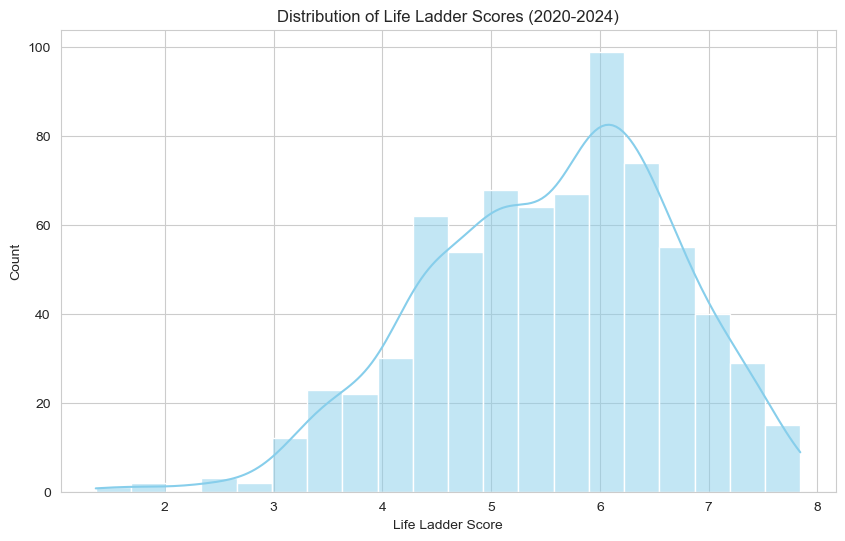

In [240]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Life_Evaluation(3yr_Avg)'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Life Ladder Scores (2020-2024)')
plt.xlabel('Life Ladder Score')
plt.show()


The histogram shows a left-skewed distribution. This indicates that while the median happiness is relatively high (around 6.0), there is a long tail of nations with very low scores.

<a id="part-3"></a>
## Part 3: Multivariate Analysis & Visualization


**1. Correlation Heatmap: Generate a heatmap for the six primary metrics (GDP, Social Support, Health, Freedom, Generosity, Corruption).**

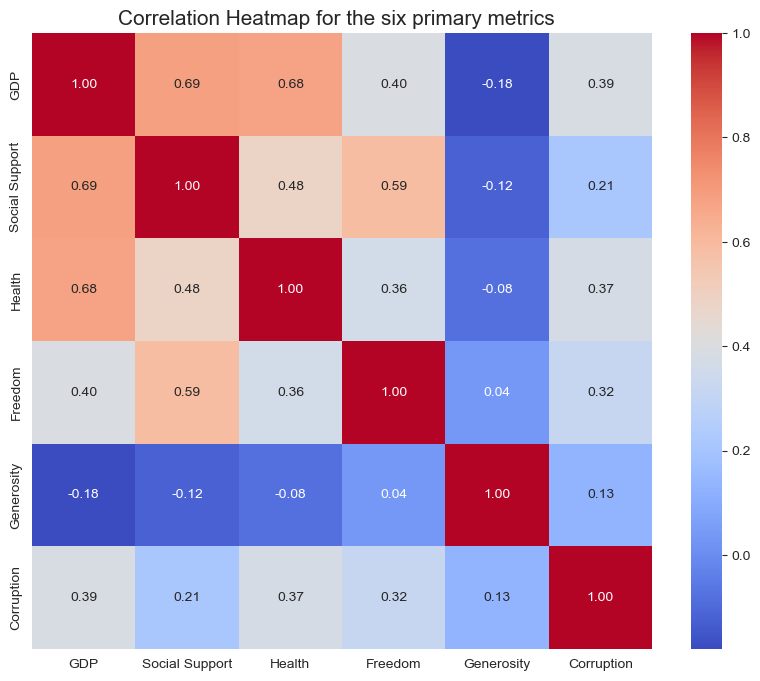

In [241]:
# Correlation Heatmap
# 1. mapping dictionary
label_map = {
    'Log_GDP': 'GDP',
    'Social_Support': 'Social Support',
    'Healthy_Life_Expectancy': 'Health',
    'Freedom': 'Freedom',
    'Generosity_index': 'Generosity',
    'Corruption_index': 'Corruption'
}

# 2. Select metrics
metrics = ['Log_GDP', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity_index', 'Corruption_index']

# 3. Plotting with renamed labels
plt.figure(figsize=(10, 8))

# Using .rename() here just for the plot display
correlation_matrix = df_clean[metrics].rename(columns=label_map).corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap for the six primary metrics  ', fontsize=15)
plt.show()


**2. The "Drivers of Happiness" Chart: Create one high-quality visualization that compares at least three variables (e.g., Happiness Score vs. GDP, colored by region).**


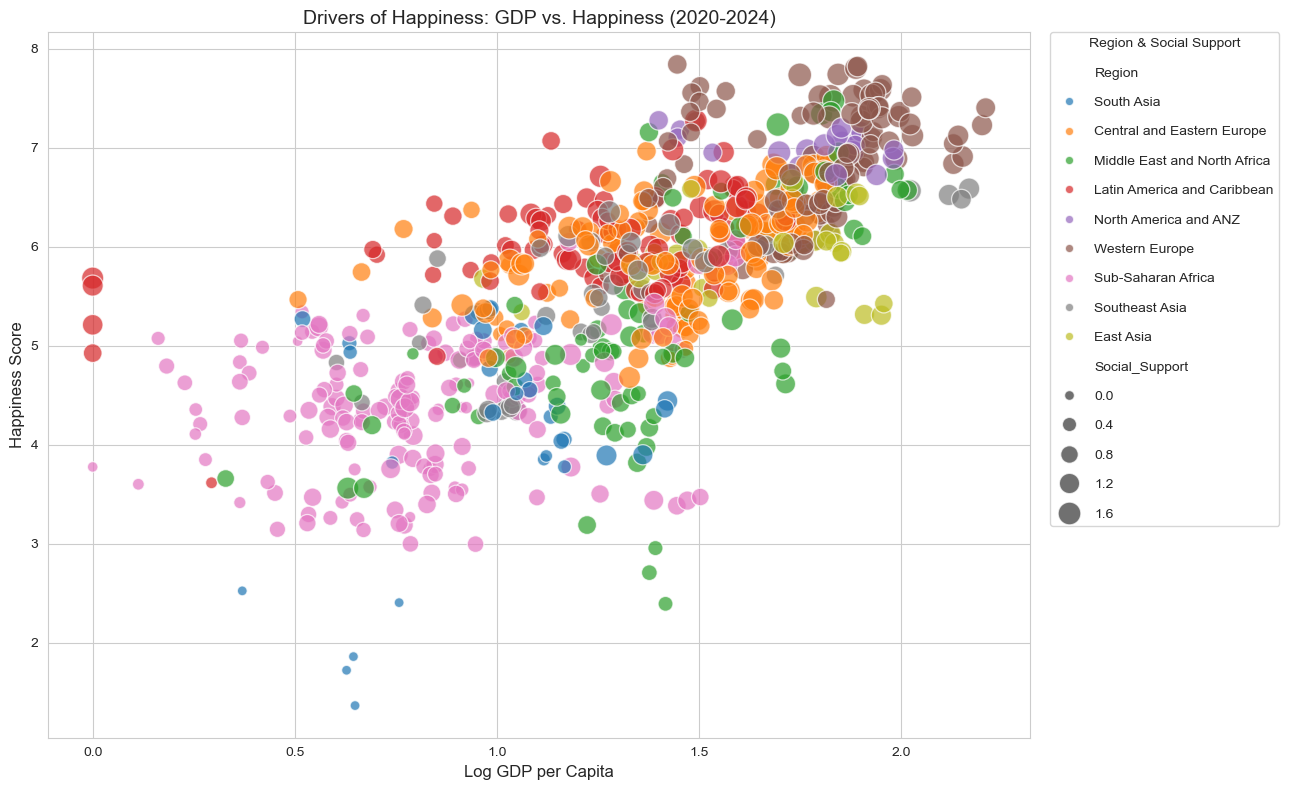

In [242]:
# Create the figure with extra width for the legend
plt.figure(figsize=(13, 8))

# Main Scatter Plot
sns.scatterplot(
    data=df_clean, 
    x='Log_GDP', 
    y='Life_Evaluation(3yr_Avg)', 
    hue='Region', 
    size='Social_Support', 
    sizes=(50, 300), 
    alpha=0.7,
    palette='tab10' # Distinct colors
)

# Titles and Labels
plt.title('Drivers of Happiness: GDP vs. Happiness (2020-2024)', fontsize=14)
plt.xlabel('Log GDP per Capita', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)


plt.legend(
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0, 
    labelspacing=1.2,  # Increases vertical space between items
    title="Region & Social Support"
)

plt.tight_layout()
plt.show()

**3. Provide a 2-3 sentence analysis of a "surprising" relationship found in the data (e.g., the "Latin American Paradox" where happiness is higher than GDP would predict).**

One of the most surprising relationships in the data is the presence of significant "Happiness Outliers" in Latin America and the Caribbean. While these nations often have lower Log GDP per Capita (around $0.0$ to $1.0$) compared to Western Europe, they frequently achieve Life Ladder Scores (between $5.0$ and $6.5$) that rival much wealthier nations. This suggests that factors like strong Social Support,indicated by the larger bubble sizes in that region,may play a more critical role in overall happiness than pure economic wealth alone.

<a id="part-4"></a>
## 4. Data Methodology Challenge


**1. Identify one potential sampling bias that could occur in a conflict-affected region or a highly rural nation.**

**Sampling Bias**: Undercoverage Bias. In conflict-affected nations, pollsters cannot safely access war zones or remote rural areas, meaning the sample is drawn primarily from safer, more accessible urban centers


**2. How might this bias lead to an "overestimation" or "underestimation" of the national Life Ladder score?**

**Direction of Error**: This leads to an overestimation of the national happiness score. The excluded populations (e.g., refugees, villagers in conflict zones) likely have lower well-being than the accessible urban population. Excluding the "lowest" values from the dataset artificially inflates the average

### **References**

Matplotlib Development Team. (2024). *Legend guide*. Matplotlib 3.8.2 documentation. https://matplotlib.org/stable/users/explain/axes/legend_guide.html


Pandas Development Team. (2024). *Group by: split-apply-combine*. Pandas documentation. https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html


